In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from cdt.data import AcyclicGraphGenerator

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


Randomly generated acyclic adjacency matrix:
[[0 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]]


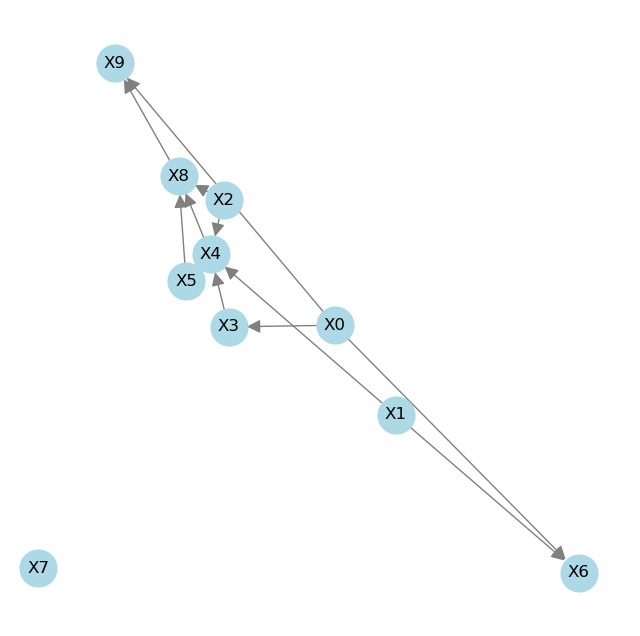

Select the relationship to use:
1: Linear
2: Polynomial
3: Gaussian Process
4: Sigmoid
5: Randomly initialized Neural Network
          V0        V1        V2        V3        V4        V5        V6  \
0  -1.149083  0.404166  1.558972 -1.278846 -1.121088 -1.225995 -1.003858   
1  -1.545850  0.386788  1.329857 -1.108602 -1.052723 -1.279284 -1.575794   
2   0.186102  0.490109  0.747683 -0.061612  0.171537  0.368194  0.581173   
3  -0.137391  0.410313  1.362855 -0.180053  0.081163  0.192739  0.079098   
4   0.220079  0.682122  1.218526 -0.280601 -0.177139  0.062578  0.555671   
..       ...       ...       ...       ...       ...       ...       ...   
95 -0.872489  0.135791 -1.373049 -0.582141 -0.591724 -0.595345 -0.854398   
96 -1.191338  0.167802 -1.133254 -1.378057 -1.431338 -1.190008 -1.216260   
97 -1.569276  0.064836 -0.121382 -1.493625 -1.451414 -1.855353 -1.575535   
98 -1.117411 -0.119085 -0.466205 -1.161588 -1.222311 -1.148807 -1.542804   
99 -1.045881  0.109433 -0.707896 -0.84

In [2]:
class CustomAcyclicGraphGenerator(AcyclicGraphGenerator):
    """
    A custom generator that uses a user-defined adjacency matrix
    to specify the causal graph structure. This class overrides the
    init_dag part of the base AcyclicGraphGenerator class in cdt.
    """
    
    def __init__(self, adjacency_matrix, causal_mechanism, **kwargs):
        
        # Get the number of nodes from the adjacency matrix
        nodes = adjacency_matrix.shape[0]
        super().__init__(causal_mechanism, nodes=nodes, **kwargs)
        # Store the provided adjacency matrix
        self.custom_adjacency_matrix = adjacency_matrix.copy()
    
    def init_dag(self, verbose=False):
        # Use the adjacency matrix we want (and not a random one as in the existing AcyclicGraphGenerator)
        self.adjacency_matrix = self.custom_adjacency_matrix.copy()
        
        # Create networkx graph and verify it's acyclic
        self.g = nx.DiGraph(self.adjacency_matrix)
        if list(nx.simple_cycles(self.g)):
            raise ValueError("Error: provided adjacency matrix contains cycles.")


num_features = int(input("Enter the number of features of the generated dataset: "))
num_datapoints = int(input("Enter the number of datapoints in the generated dataset: "))

# Create an empty adjacency matrix
input_adjacency_matrix = np.zeros((num_features, num_features), dtype=int)

# Fill the matrix with random numbers only in the upper triangle (sufficient for it to be acyclic)
input_adjacency_matrix[np.triu_indices(num_features, 1)] = np.random.randint(0, 2, size=int(num_features * (num_features - 1) / 2))

if num_features <= 10:
    print("Randomly generated acyclic adjacency matrix:")
    print(input_adjacency_matrix)

    # Visualise the graph
    G = nx.from_numpy_array(input_adjacency_matrix, create_using=nx.DiGraph)
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G)
    nx.draw_networkx(
        G, 
        pos, 
        with_labels=True, 
        node_color='lightblue', 
        node_size=700, 
        edge_color='gray', 
        arrows=True, 
        arrowsize=20,
        labels={i: f'X{i}' for i in range(num_features)}
    )
    plt.axis('off')
    plt.show()

# input_adjacency_matrix = np.array([
#     [0, 1, 0, 1],
#     [0, 0, 1, 0], 
#     [0, 0, 0, 1],
#     [0, 0, 0, 0]
# ])

causal_mechanisms = {
    '1': 'linear',
    '2': 'polynomial',
    '3': 'gaussian_process',
    '4': 'sigmoid',
    '5': 'nn'
}

# Ask the user for the relationship
print("Select the relationship to use:")
print("1: Linear")
print("2: Polynomial")
print("3: Gaussian Process")
print("4: Sigmoid")
print("5: Randomly initialized Neural Network")
user_choice = input("Enter your choice (1-5): ")

generator = CustomAcyclicGraphGenerator(
    adjacency_matrix=input_adjacency_matrix,
    causal_mechanism=causal_mechanisms[user_choice],
    npoints=num_datapoints
)

data, graph = generator.generate()
data.to_csv('generated_causal_data.csv', index=False)
if num_features <= 10:
    print(data)